# PS4E2 - EDA

# Configuration

In [1]:
class CFG:
    seed = 42
    n_folds = 10
    
    model_names = 'all'
#     model_names = ['lgbm', 'knn']
    
    early_stopping_rounds = 30

# Import Libraries

In [2]:
# General
import numpy as np
import pandas as pd
import gc
import time
import tqdm

# EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold

# Modelling
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier,\
    ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Import Data

In [3]:
df_train = pd.read_csv("/kaggle/input/playground-series-s4e2/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s4e2/test.csv")

df_train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

There are no missing values!

In [5]:
for col in df_train.select_dtypes(exclude=[np.number]):
    print(f"Unique values of {col}: {df_train[col].unique()}")

Unique values of Gender: ['Male' 'Female']
Unique values of family_history_with_overweight: ['yes' 'no']
Unique values of FAVC: ['yes' 'no']
Unique values of CAEC: ['Sometimes' 'Frequently' 'no' 'Always']
Unique values of SMOKE: ['no' 'yes']
Unique values of SCC: ['no' 'yes']
Unique values of CALC: ['Sometimes' 'no' 'Frequently']
Unique values of MTRANS: ['Public_Transportation' 'Automobile' 'Walking' 'Motorbike' 'Bike']
Unique values of NObeyesdad: ['Overweight_Level_II' 'Normal_Weight' 'Insufficient_Weight'
 'Obesity_Type_III' 'Obesity_Type_II' 'Overweight_Level_I'
 'Obesity_Type_I']


We see that there are a lot of classes in our response, and there are many binary categorical variates.

# Exploratory Data Analysis

## Countplot of Response

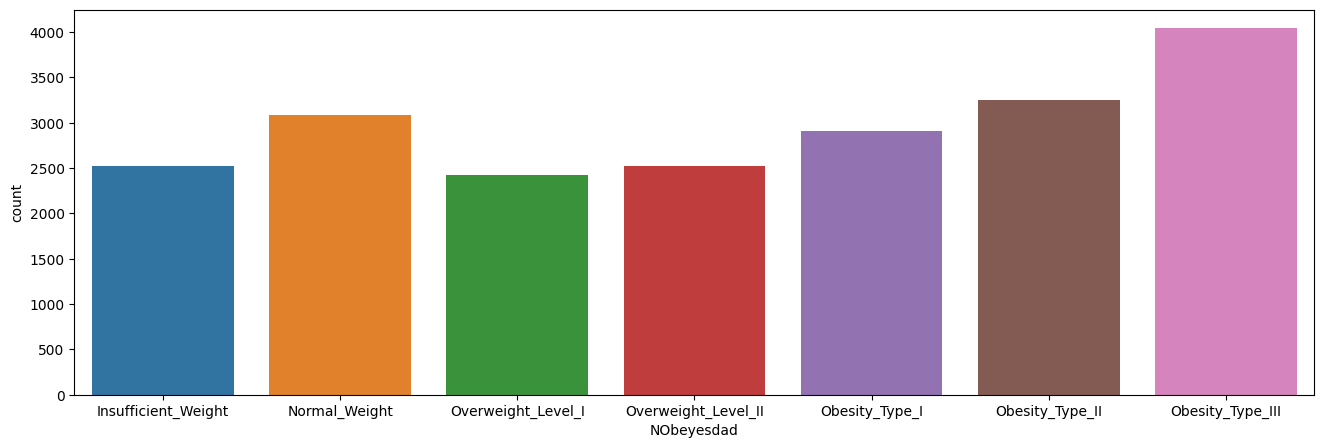

In [6]:
plt.figure(figsize=(16, 5))

response_col = "NObeyesdad"
response_order = ["Insufficient_Weight", "Normal_Weight", 
                  "Overweight_Level_I", "Overweight_Level_II", 
                  "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]

sns.countplot(data=df_train, x=response_col, order=response_order)
plt.show()

The classes seem to be evenly distributed.

## Graphs of Numeric Variates

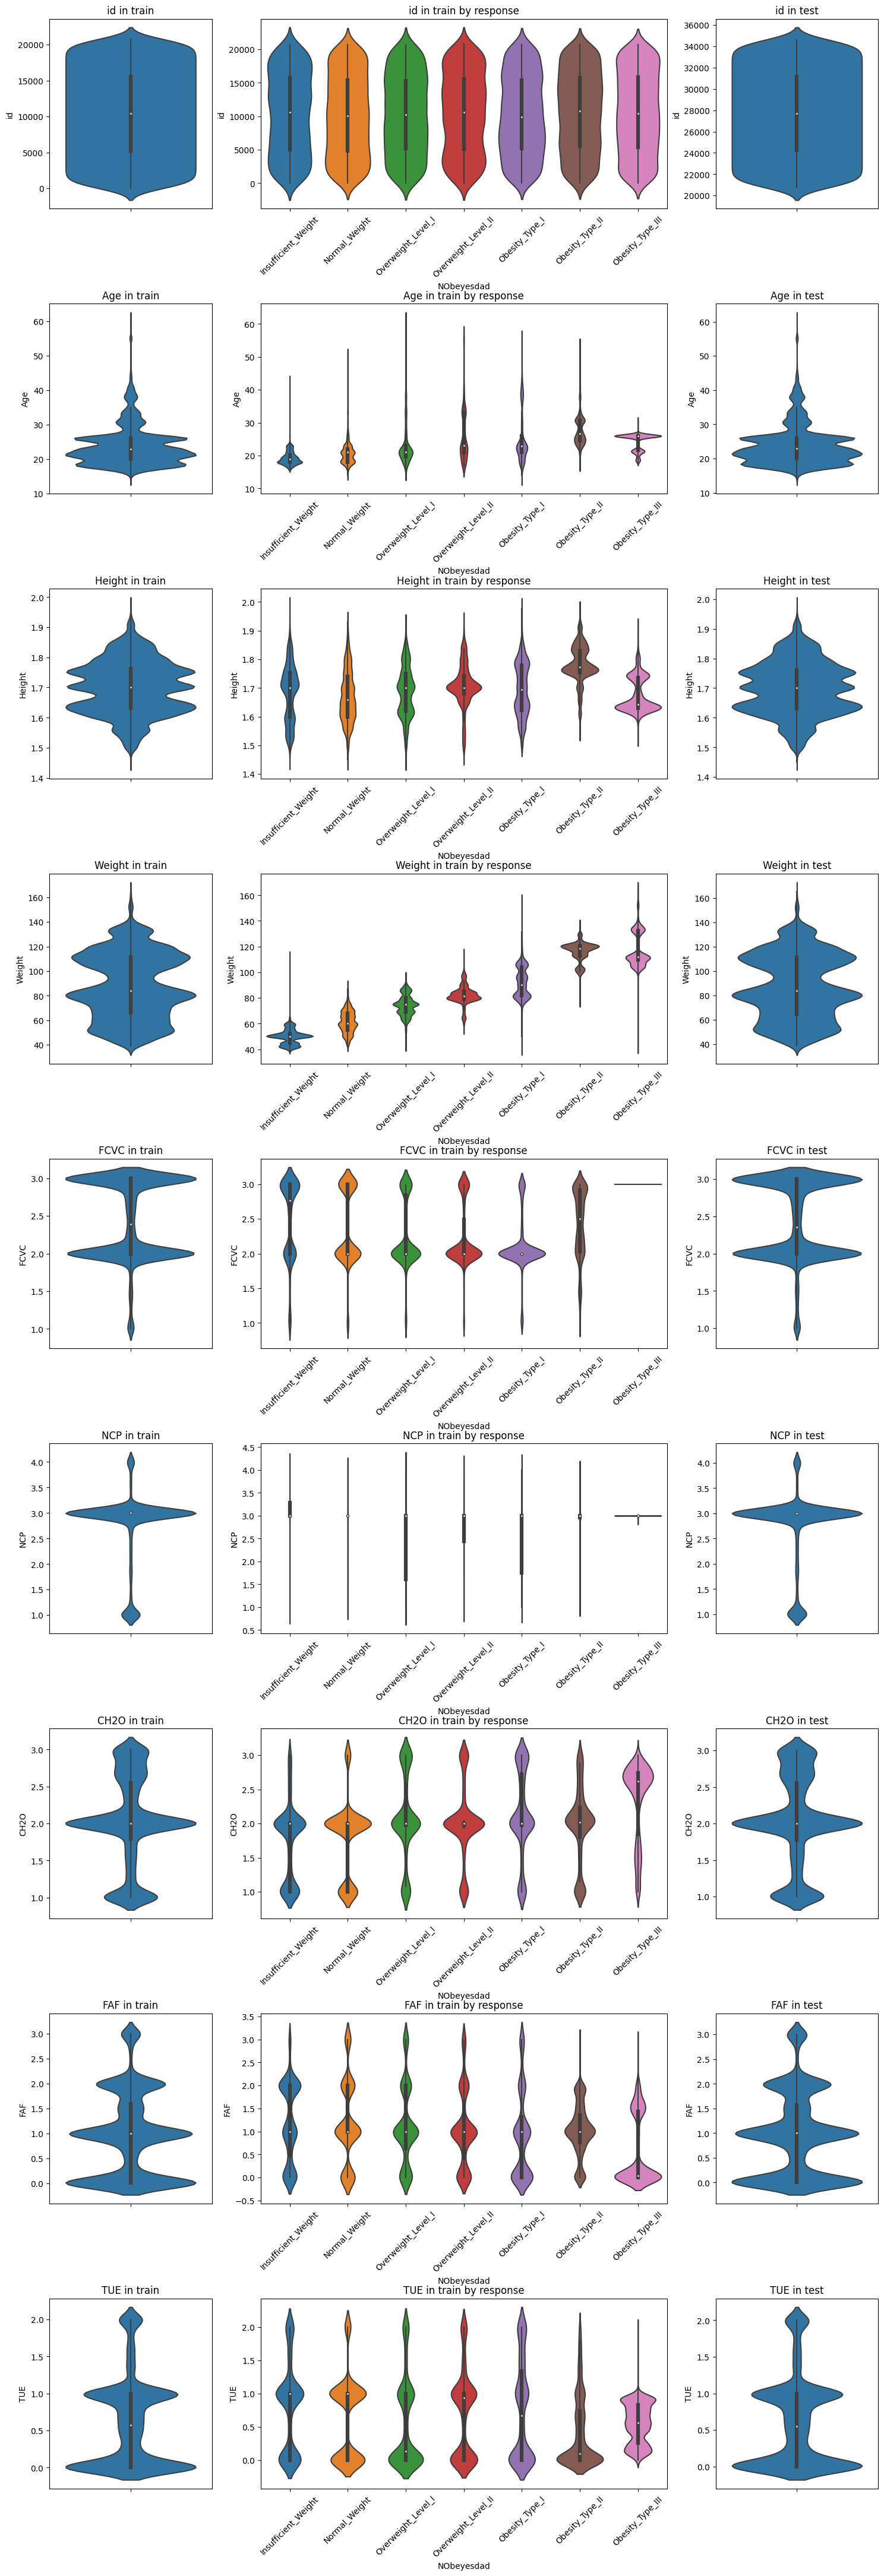

In [7]:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(
    nrows=len(numeric_cols), ncols=3, 
    figsize=(18, len(numeric_cols) * 6),
    width_ratios=[4, 10, 4]
)
plt.subplots_adjust(
    wspace=0.2, 
    hspace=0.5)

for row_idx, col in enumerate(numeric_cols):
    sns.violinplot(data=df_train, y=col, ax=axes[row_idx][0])
    axes[row_idx][0].set_title(f"{col} in train")
    
    sns.violinplot(data=df_train, y=col, x=response_col, order=response_order, ax=axes[row_idx][1])
    axes[row_idx][1].set_title(f"{col} in train by response")
    axes[row_idx][1].tick_params(axis='x', labelrotation=45)
    
    sns.violinplot(data=df_test, y=col, ax=axes[row_idx][2])
    axes[row_idx][2].set_title(f"{col} in test")

The degree of obesity in an individual mostly will depend on their weight and their height, so it might be a good idea to plot individuals' weights and heights and categorize them based on their overweight class.

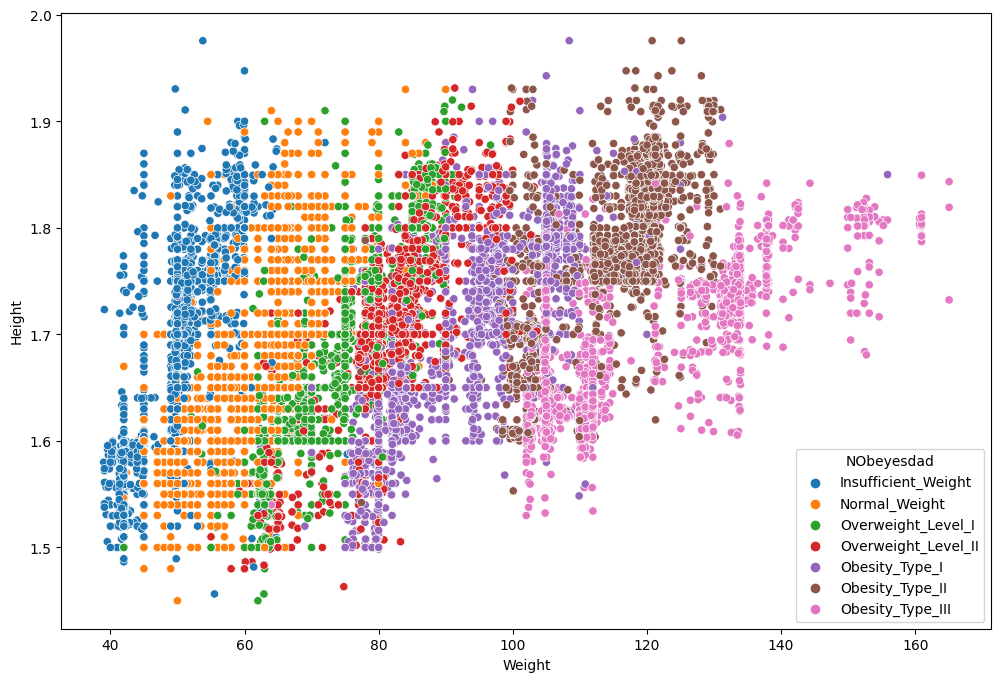

In [8]:
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(data=df_train, x='Weight', y='Height', 
                     hue=response_col, hue_order=response_order)
plt.show()

We see that the heights and weights are clearly clustered into bands. 

## Graphs of Categorical Variates

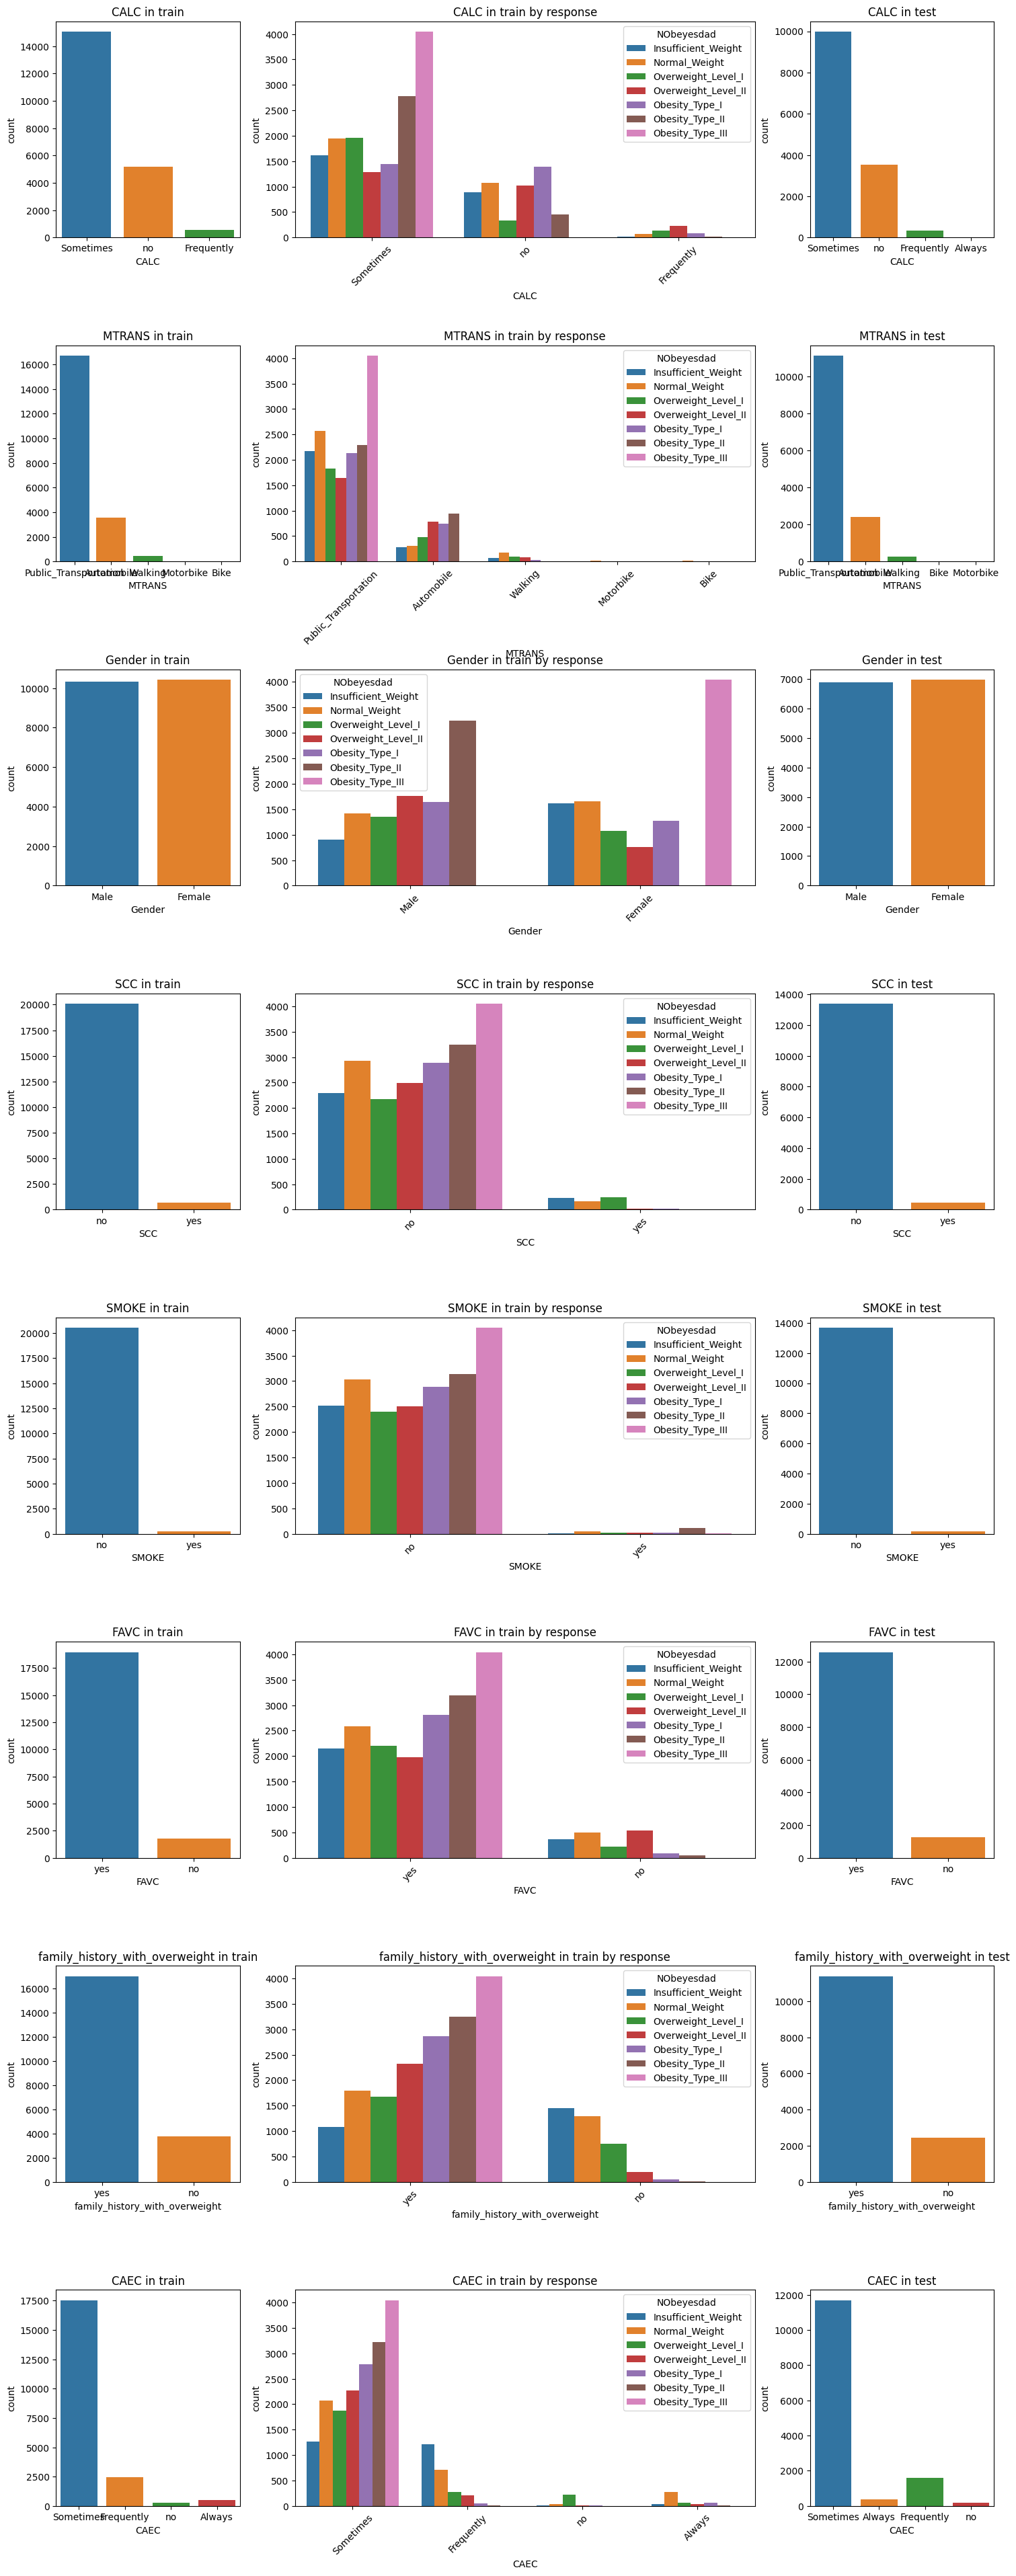

In [9]:
categorical_cols = df_train.select_dtypes(exclude=[np.number]).columns
categorical_cols = list(set(categorical_cols).difference(set([response_col])))

fig, axes = plt.subplots(
    nrows=len(categorical_cols), ncols=3, 
    figsize=(18, len(categorical_cols) * 6),
    width_ratios=[4, 10, 4]
)
plt.subplots_adjust(
    wspace=0.2, 
    hspace=0.5)

for row_idx, col in enumerate(categorical_cols):
    sns.countplot(data=df_train, x=col, ax=axes[row_idx][0])
    axes[row_idx][0].set_title(f"{col} in train")
    
    sns.countplot(data=df_train, x=col, hue=response_col, hue_order=response_order, ax=axes[row_idx][1])
    axes[row_idx][1].set_title(f"{col} in train by response")
    axes[row_idx][1].tick_params(axis='x', labelrotation=45)
    
    sns.countplot(data=df_test, x=col, ax=axes[row_idx][2])
    axes[row_idx][2].set_title(f"{col} in test")

# Score (Accuracy)

In [10]:
# This score is essentially the accuracy, but pred should be a dataframe of *probabilities*
# instead of the actual value themselves
def score(act, pred):
    pred_labels = [response_order[idx] for idx in np.argmax(pred, axis=1)]
    return accuracy_score(act, pred_labels)

# Feature Engineering

In [11]:
class Preprocessor:
    
    def __init__(self):
        self.encoder = OneHotEncoder(handle_unknown='ignore')
        self.imputer = KNNImputer()
        
    def fit(self, df: pd.DataFrame):
        X_cat = df[categorical_cols]
        X_num = df[numeric_cols]
        
        # Train encoder
        self.encoder.fit(X_cat)
        # Train imputer
        self.imputer.fit(X_num)
    
    def preprocess(self, df: pd.DataFrame):
        df['bmi'] = df['Weight'] / (df['Height'] ** 2)
        
        # Replace categorical columns with their encoded counterparts
        X_cat = df[categorical_cols]
        encoded_cols = []
        for col, categories in zip(categorical_cols, self.encoder.categories_):
            encoded_cols.extend([f"{col}_{cat}" for cat in categories])
        encoded_cat_df = pd.DataFrame(
            self.encoder.transform(X_cat).toarray(),
            columns=encoded_cols
        )
        df = pd.concat([df, encoded_cat_df], axis=1)
        df.drop(columns=categorical_cols, inplace=True)
        
        return df

In [12]:
preprocessor = Preprocessor()
preprocessor.fit(df_train)

df_train = preprocessor.preprocess(df_train)
df_test = preprocessor.preprocess(df_test)

del preprocessor
gc.collect()

98394

In [13]:
print(f"Shape of new combined dataframe: {df_train.shape}")
print(f"Shape of new test dataframe: {df_test.shape}")

Shape of new combined dataframe: (20758, 33)
Shape of new test dataframe: (13840, 32)


In [14]:
df_train.head()

,id,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,...,SMOKE_no,SMOKE_yes,FAVC_no,FAVC_yes,family_history_with_overweight_no,family_history_with_overweight_yes,CAEC_Always,CAEC_Frequently,CAEC_Sometimes,CAEC_no
0,0,24.443011,1.699998,81.669950,2.000000,2.983297,2.763573,0.000000,0.976473,Overweight_Level_II,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,18.000000,1.560000,57.000000,2.000000,3.000000,2.000000,1.000000,1.000000,Normal_Weight,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
2,2,18.000000,1.711460,50.165754,1.880534,1.411685,1.910378,0.866045,1.673584,Insufficient_Weight,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,3,20.952737,1.710730,131.274851,3.000000,3.000000,1.674061,1.467863,0.780199,Obesity_Type_III,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
4,4,31.641081,1.914186,93.798055,2.679664,1.971472,1.979848,1.967973,0.931721,Overweight_Level_II,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


# Split Data Into Folds

In [15]:
kfold = KFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
for fold, (_, val_idx) in enumerate(kfold.split(df_train)):
    df_train.loc[val_idx, "fold"] = fold

# Modelling

## Single Model Wrapper Class

In [16]:
class MyModel:
    """
    Class that encapsulates our model.
    
    Attributes:
    - model_name: name of the model.
    - params: parameters for the model.
    - transformer_name: the name of the transformer to use.
    """
    
    def __init__(self, model_name: str, params: dict, transformer_name: str = None):
        self.model_name = model_name
        self.transformer_name = transformer_name
        self.model = self.create_model(params)
    
    # To be used later
    def make_pipeline(self, model):
        pipeline = None

        if self.transformer_name == 'robust_scaler':
            pipeline = Pipeline([
                ('scaler', RobustScaler()),
                ('normalizer', FunctionTransformer(np.log1p)),
                ('model', model)
            ])
        elif self.transformer_name == 'min_max_scaler':
            pipeline = Pipeline([
                ('normalizer', PowerTransformer()),
                ('model', model)
            ])
        elif self.transformer_name == None:
            pipeline = Pipeline([
                ('model', model)
            ])

        return pipeline

    def create_model(self, params):
        modelf = {
            'lgbm': lgb.LGBMClassifier,
            'xgb': xgb.XGBClassifier,
            'cat': cb.CatBoostClassifier,
            'hgb': HistGradientBoostingClassifier,
            'rf': RandomForestClassifier,
            'et': ExtraTreesClassifier,
            'nb': GaussianNB,
            'knn': KNeighborsClassifier,
            'lr': LogisticRegression,
        }[self.model_name]
        
        model = modelf(**params)
        return model

    def train(self, X_train: np.array, Y_train: np.array, 
              X_val: np.array, Y_val: np.array, 
              early_stopping_rounds: int):
        """
        Train the model.
        - X_train: training dataset with explanatory variables.
        - Y_train: training dataset with the response variable.
        - X_val: validation dataset with explanatory variables.
        - Y_val: validation dataset with the response variable.
        - early_stopping_rounds: the number of rounds to use for early stopping,
        if the model training supports it.
        """
        if self.model_name == 'lgbm':
            early_stopping_callback = lgb.early_stopping(
                early_stopping_rounds,
                first_metric_only=True, 
                verbose=False)

            self.model.fit(X_train,
                      Y_train,
                      eval_set=[(X_val, Y_val)],
                      eval_metric='multiclass',
                      callbacks=[early_stopping_callback])

        elif self.model_name == 'xgb':
            # We need to transform "Y_train" and "Y_val" into a label encoding
            # in order to make it work with xgboost.
            # The beauty of an encapsulated class is that we can just "hide" this in the
            # bigger model class, so we can treat xgb like everything else.
            ve = np.vectorize(lambda x: response_col_order.index(x))
            Y_train = ve(Y_train)
            Y_val = ve(Y_val)
            
            self.model.fit(X_train,
                      Y_train)
#                       eval_set=[(X_val, Y_val)],
#                       early_stopping_rounds=early_stopping_rounds)

        elif self.model_name == 'cat':
            self.model.fit(X_train,
                      Y_train,
                      eval_set=[(X_val, Y_val)],
                      verbose=0,
                      early_stopping_rounds=early_stopping_rounds)
        else:
            self.model.fit(X_train, Y_train)

        return self.model
    
    def validate(self, X_val, Y_val):
        """
        Predict and score on the validation dataset.
        Returns a tuple of the predicted values, as well as the score.
        
        Attributes:
        - X_val: validation dataset with explanatory variables.
        - Y_val: validation dataset with the response variable.
        """
        pred = self.predict_proba(X_val)
        loss = score(pred = pred, act = Y_val)
        return pred, loss
    
    def predict(self, X_test):
        """
        Predict the test set of explanatory variates.
        """
        return self.model.predict(X_test)
    
    def predict_proba(self, X_test):
        """
        Predict the test set of explanatory variates.
        """
        prob_arr = pd.DataFrame(self.model.predict_proba(X_test), columns=self.model.classes_)
        return prob_arr[response_order]

## Select Features

In [17]:
feature_names = [c for c in df_train.columns if c not in ['id', 'fold', response_col]]
print(f"Total number of features: {len(feature_names)}")

Total number of features: 31


# KFold Trainer Class

In [18]:
class KFoldTrainer:
    """Responsible for training a model using k-fold cross validation"""
    
    def __init__(self, seed: int, model_name: str, model_params: dict):
        self.seed = seed
        self.model_name = model_name
        self.model_params = model_params
        
        # [fold]: model
        self.saved_models = {}
        
    def train_by_fold(self, df: pd.DataFrame, feature_names: list[str], verbose: bool = False):
        for fold in range(CFG.n_folds):
            if verbose:
                print(f"Training for FOLD {fold}")
                
            X_train = df[df["fold"] != fold][feature_names]
            Y_train = df[df["fold"] != fold][response_col]

            X_val = df[df["fold"] == fold][feature_names]
            Y_val = df[df["fold"] == fold][response_col]

            model = MyModel(self.model_name, self.model_params)
            model.train(
                X_train.values, Y_train.values, 
                X_val.values, Y_val.values,
                early_stopping_rounds = CFG.early_stopping_rounds
            )

            self.saved_models[fold] = model
    
    def get_saved_models(self):
        return self.saved_models
    
    # returns (df_pred, metric, fold_metrics, mean_fold_metric, sd_fold_metric)
    def get_oof_predictions_and_metric(self, df: pd.DataFrame, feature_names: list[str], verbose: bool = False):
        df_pred = pd.DataFrame({'index': df.index}).set_index('index')
        pred_cols = [f"pred_{c}" for c in response_order]
        fold_metrics = []
        for fold in range(CFG.n_folds):
            if verbose:
                print(f"Validating for FOLD {fold}")
                
            X_val = df[df["fold"] == fold][feature_names]
            Y_val = df[df["fold"] == fold][response_col]
            pred_fold = self.saved_models[fold].predict(X_val.values)
            pred_proba_fold = self.saved_models[fold].predict_proba(X_val.values).values
            
            df_pred.loc[X_val.index, pred_cols] = pred_proba_fold
            df_pred.loc[X_val.index, "pred"] = pred_fold
            
            fold_metric = score(pred=pred_proba_fold, act=Y_val.values)
            fold_metrics.append(fold_metric)
            
        metric = score(
            act = df[response_col], 
            pred=df_pred[pred_cols]
#             pred = df_pred['pred']
        )
        mean_fold_metric, sd_fold_metric = np.mean(fold_metrics), np.std(fold_metrics)
        return df_pred[pred_cols].values, df_pred['pred'].values, metric, fold_metrics, mean_fold_metric, sd_fold_metric
    
    def predict(self, df: pd.DataFrame, feature_names: list[str], verbose: bool = False):
        df_pred = pd.DataFrame({'index': df.index}).set_index('index')
        for fold in range(CFG.n_folds):
            if verbose:
                print(f"Predicting for FOLD {fold}")
            X_test = df[feature_names]
            pred = self.saved_models[fold].predict_proba(X_test.values)
            df_pred[[f"pred_{c}_{fold}" for c in response_order]] = pred
        
        for c in response_order:
            df_pred[f"pred_{c}"] = \
                df_pred[[f"pred_{c}_{fold}" for fold in range(CFG.n_folds)]] \
                .mean(axis=1)
            
        return df_pred[[f"pred_{c}" for c in response_order]].values

# Model Parameters

(to be hyperparameter tuned later)

In [19]:
model_params_dict: dict[str, dict] = {
    # https://lightgbm.readthedocs.io/en/latest/Parameters.html
    'lgbm': {
        'objective': 'multiclass',
        'num_class': 3,
        'n_estimators': 512,
#         'n_estimators': 50,
        'verbosity': -1,
        'seed': CFG.seed,
    },
    # https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
    # https://stackoverflow.com/questions/57986259/multiclass-classification-with-xgboost-classifier
    # XGB keeps throwing "verbosity = -1" errors. stack overflow does not help, so I'm omitting it
    # for now
    #     'xgb': {
#         'random_state': CFG.seed,
# #         'verbosity': 0,
# #         'booster': 'gbtree',
#         'n_estimators': 5,
# #         'objective': 'multi:softmax',
#     },
#     'cat': {
#         'random_state': CFG.seed,
#     },
    'hgb': {
        
    },
    'et': {
        
    },
    'rf': {
        
    },
    'nb': {
        
    },
    'knn': {
        
    },
}

# Select Models

In [20]:
if CFG.model_names == 'all':
    model_names = model_params_dict.keys()
else:
    model_names = CFG.model_names
assert len(model_names) > 0, "At least one model must be used"

print(f"Number of models being used: {len(model_names)}")
print(f"Models being used: {list(model_names)}")

Number of models being used: 6
Models being used: ['lgbm', 'hgb', 'et', 'rf', 'nb', 'knn']


# Training, Validation, Prediction

In [21]:
model_scores = []
model_fold_scores = []
models_dict = {}

for idx, model_name in enumerate(model_names):
    
    pred_cols = [f"pred_{response_col}_{c}_{model_name}" for c in response_order]
    
    print("="*25)
    print(f"Starting training, validation and prediction for model {model_name} [MODEL {idx+1}/{len(model_names)}]")
    print("="*25)
    
    print("-"*25)
    print(f"Training model:")
    print("-"*25)
    
    start_time = time.process_time()
    
    trainer = KFoldTrainer(
        seed = CFG.seed,
        model_name = model_name,
        model_params = model_params_dict[model_name],
    )
    # training
    trainer.train_by_fold(df_train, feature_names, verbose=True)
    print("-"*25)
    
    models_dict[model_name] = trainer.get_saved_models()
    
    # validation
    pred_proba_train, pred_train, metric, fold_metrics, mean_fold_metric, sd_fold_metric = \
        trainer.get_oof_predictions_and_metric(df_train, feature_names)
    
    df_train[pred_cols] = pred_proba_train
    
    for fold in range(CFG.n_folds):
        print(f"SCORE for FOLD {fold}: {fold_metrics[fold]:6f}")
    print()
    print(f"OOF SCORE for {model_name}: {metric:.6f}")
    print(f"Mean/SD SCORE for {model_name}: {mean_fold_metric:.6f} ± {sd_fold_metric:.6f}")
    
    # for plotting later on
    model_scores.append({
        'model_name': model_name,
        'score': metric,
    })
    model_fold_scores.extend([{
        'model_name': model_name,
        'fold': fold,
        'score': fold_metrics[fold]
    } for fold in range(CFG.n_folds)])
    
    # prediction (test set)
    print("-"*25)
    print(f"Predicting test set with model:")
    print("-"*25)
    df_test[pred_cols] = trainer.predict(df_test, feature_names, verbose=True)
    
    # cleanup
    del trainer, pred_train, metric, fold_metrics, mean_fold_metric, sd_fold_metric
    gc.collect()

Starting training, validation and prediction for model lgbm [MODEL 1/6]
-------------------------
Training model:
-------------------------
Training for FOLD 0
Training for FOLD 1
Training for FOLD 2
Training for FOLD 3
Training for FOLD 4
Training for FOLD 5
Training for FOLD 6
Training for FOLD 7
Training for FOLD 8
Training for FOLD 9
-------------------------
SCORE for FOLD 0: 0.907033
SCORE for FOLD 1: 0.901734
SCORE for FOLD 2: 0.900771
SCORE for FOLD 3: 0.902697
SCORE for FOLD 4: 0.900771
SCORE for FOLD 5: 0.898844
SCORE for FOLD 6: 0.907033
SCORE for FOLD 7: 0.911368
SCORE for FOLD 8: 0.906988
SCORE for FOLD 9: 0.916145

OOF SCORE for lgbm: 0.905338
Mean/SD SCORE for lgbm: 0.905338 ± 0.005152
-------------------------
Predicting test set with model:
-------------------------
Predicting for FOLD 0
Predicting for FOLD 1
Predicting for FOLD 2
Predicting for FOLD 3
Predicting for FOLD 4
Predicting for FOLD 5
Predicting for FOLD 6
Predicting for FOLD 7
Predicting for FOLD 8
Predicti

In [22]:
model_scores = pd.DataFrame.from_records(model_scores)
model_fold_scores = pd.DataFrame.from_records(model_fold_scores)

# Model Evaluation

## Graph of Accuracy for Each Model

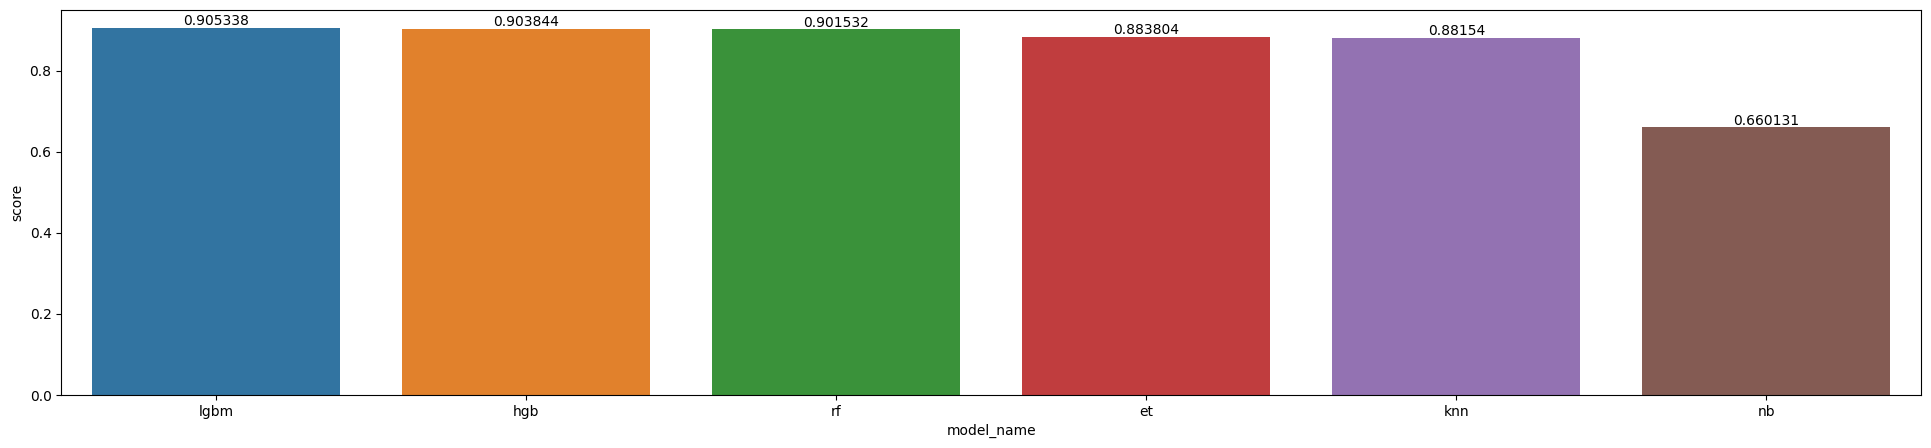

In [23]:
plt.figure(figsize=(len(model_names)*4, 5))

ax = sns.barplot(data=model_scores.sort_values(by='score', ascending=False), x='model_name', y='score')
ax.bar_label(ax.containers[0])
plt.show()

## Boxplots of OOF Accuracy for Each Fold

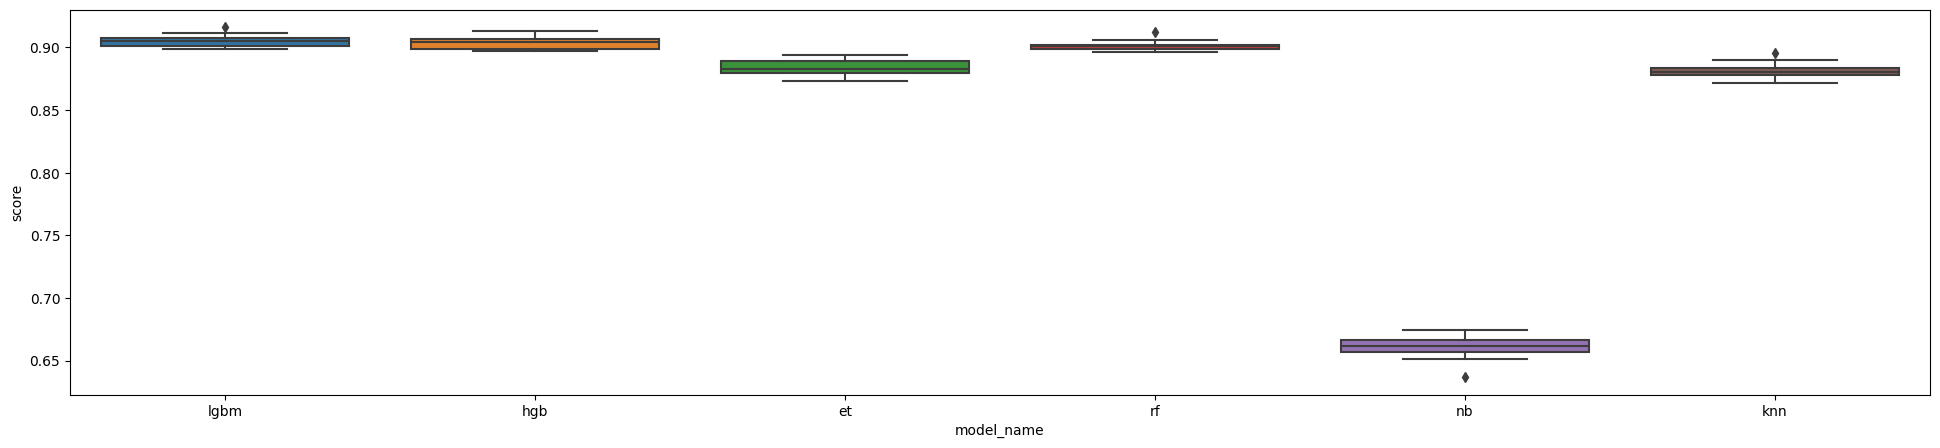

In [24]:
plt.figure(figsize=(len(model_names)*4, 5))

ax = sns.boxplot(data=model_fold_scores, x='model_name', y='score')
plt.show()

# Ensembling via Hill Climbing

In [25]:
%%time

# [(model_name, weight)]
model_weights = {}
# preds
best_ensemble_train_preds = None
best_ensemble_test_preds = None

print("-"*25)
print(f"Running hill climbing")
print("-"*25)

# Initialise
STOP = False
# [model_name]: model_weight
model_weights = {}
best_model_order = model_scores.sort_values(by='score', ascending=False)['model_name'].values
i = 0

cur_model_names = list(set(model_names).difference(set([best_model_order[0]]))).copy()
y_target = df_train[response_col].values

best_ensemble_train_preds = df_train[[f"pred_{response_col}_{c}_{best_model_order[0]}" \
                                     for c in response_order]].values
best_ensemble_test_preds = df_test[[f"pred_{response_col}_{c}_{best_model_order[0]}" \
                                   for c in response_order]].values

potential_new_best_cv_score = score(act=y_target, pred=best_ensemble_train_preds)
model_weights[best_model_order[0]] = 1
print(f"Initial best single model score ({best_model_order[0]}): {potential_new_best_cv_score}")

if len(cur_model_names) == 0:
    STOP = True
        
weight_range = np.arange(-0.5, 0.6, 0.01)

# Hill climbing
while not STOP:
    i += 1
    potential_new_best_cv_score = score(act=y_target, pred=best_ensemble_train_preds)
    k_best, model_name_best, wgt_best = None, None, None
    for k, model_name in enumerate(cur_model_names):
        for wgt in weight_range:
            potential_ensemble = (1-wgt) * best_ensemble_train_preds + \
                                    wgt * df_train[[f"pred_{response_col}_{c}_{model_name}" \
                                                    for c in response_order]].values
            
            cv_score = score(act=y_target, pred=potential_ensemble)
            if cv_score > potential_new_best_cv_score:
                potential_new_best_cv_score = cv_score
                k_best, model_name_best, wgt_best = k, model_name, wgt

    if k_best is not None:
        best_ensemble_train_preds = (1-wgt_best) * best_ensemble_train_preds + wgt_best * df_train[[f"pred_{response_col}_{c}_{model_name_best}" \
                                                    for c in response_order]].values
        best_ensemble_test_preds = (1-wgt_best) * best_ensemble_test_preds + wgt_best * df_test[[f"pred_{response_col}_{c}_{model_name_best}" \
                                                    for c in response_order]].values

        model_weights = {model_name: model_weight * (1-wgt_best) for model_name, model_weight in model_weights.items()}
        model_weights[model_name_best] = wgt_best

        cur_model_names.remove(model_name_best)
        if len(cur_model_names) == 0:
            STOP = True
        print(f'Iteration: {i}, Model added: {model_name_best}, Best weight: {wgt_best:.5f}, Best score: {potential_new_best_cv_score:.7f}')
#             history.append(potential_new_best_cv_score)
    else:
        STOP = True

-------------------------
Running hill climbing
-------------------------
Initial best single model score (lgbm): 0.9053377011272762
Iteration: 1, Model added: knn, Best weight: 0.24000, Best score: 0.9065902
Iteration: 2, Model added: rf, Best weight: 0.24000, Best score: 0.9073128
Iteration: 3, Model added: et, Best weight: 0.02000, Best score: 0.9074092
Iteration: 4, Model added: hgb, Best weight: 0.06000, Best score: 0.9075055
CPU times: user 52 s, sys: 16.5 ms, total: 52.1 s
Wall time: 52.1 s


# Model Weights

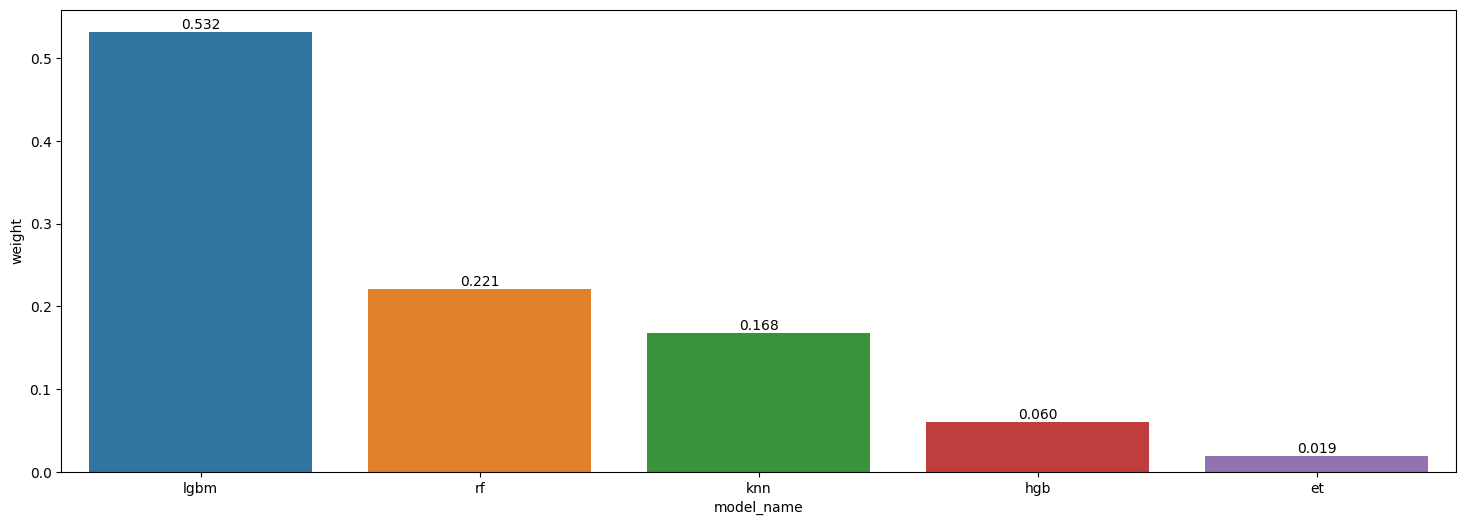

In [26]:
model_weights_df = pd.DataFrame(model_weights.items(), columns=['model_name', 'weight'])
model_weights_df.sort_values('weight', ascending=False, inplace=True)

plt.figure(figsize=(18,6))
ax = sns.barplot(data=model_weights_df, x='model_name', y='weight')
ax.bar_label(ax.containers[0], fmt='{:,.3f}')

plt.show()

# Predict with Ensemble Predictions

In [27]:
pred_ensemble_cols = [f"{response_col}_{c}" for c in response_order]
df_train[pred_ensemble_cols] = best_ensemble_train_preds
df_test[pred_ensemble_cols] = best_ensemble_test_preds

# Submission

In [28]:
df_test[response_col] = [response_order[idx] for idx in np.argmax(df_test[pred_ensemble_cols], axis=1)]
submission = df_test[['id', response_col]]
submission.to_csv('submission.csv', index=False)
submission.head()

,id,NObeyesdad
0,20758,Obesity_Type_II
1,20759,Overweight_Level_I
2,20760,Obesity_Type_III
3,20761,Obesity_Type_I
4,20762,Obesity_Type_III
